총 파일 수: 7
선택된 파일 수: 5

===== 처리 파일: 벌 소리 ASMR #양봉  (졸 수 있음).mp3 =====


c:\Users\hoons\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling Rate: 22050
Audio Length (samples): 219136
Duration (sec): 9.93814058956916


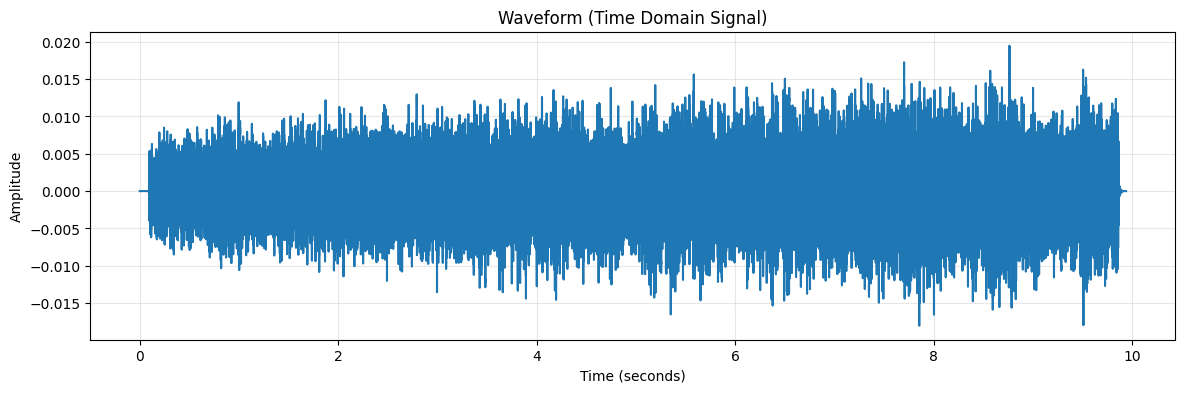

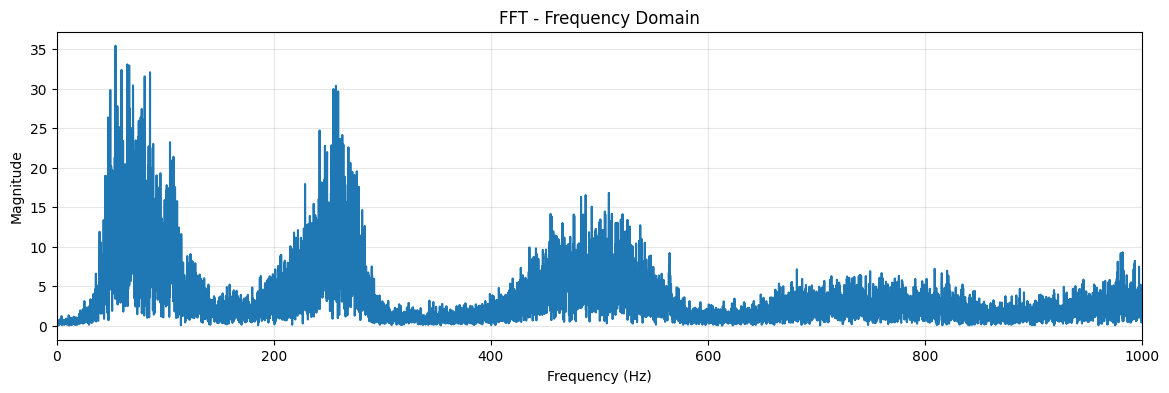

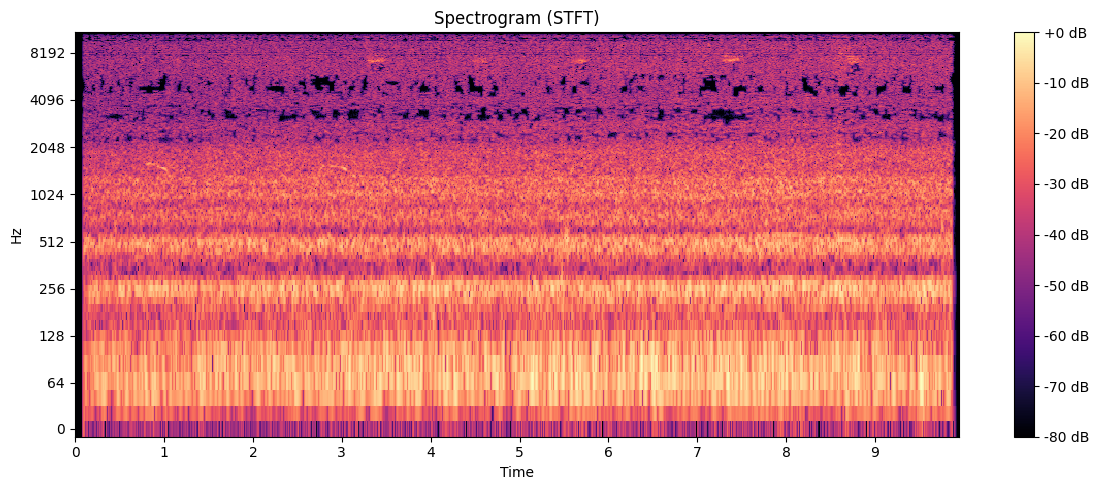


===== 분석 요약 =====
Waveform → 시간에 따른 진폭 변화
FFT → 전체 주파수 성분 분석
Spectrogram → 시간 + 주파수 동시 분석

===== 처리 파일: 꿀벌소리.mp3 =====
Sampling Rate: 22050
Audio Length (samples): 244224
Duration (sec): 11.075918367346938


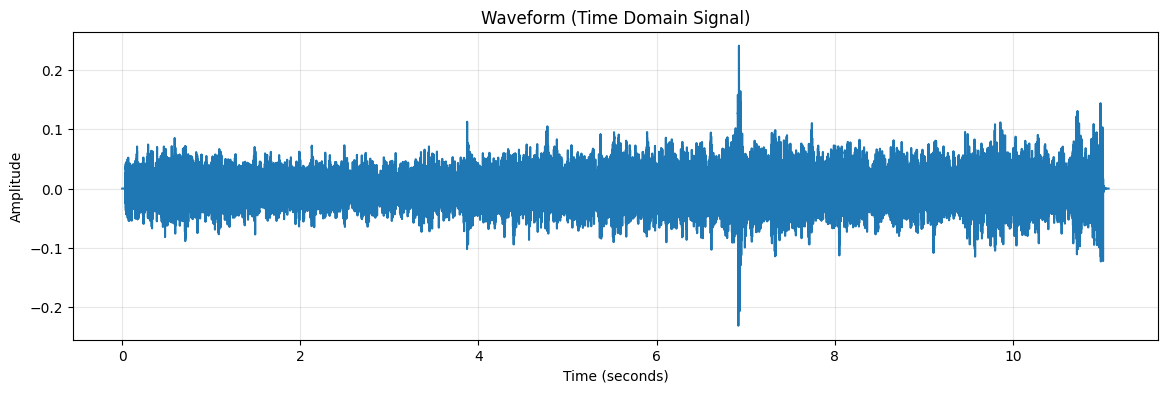

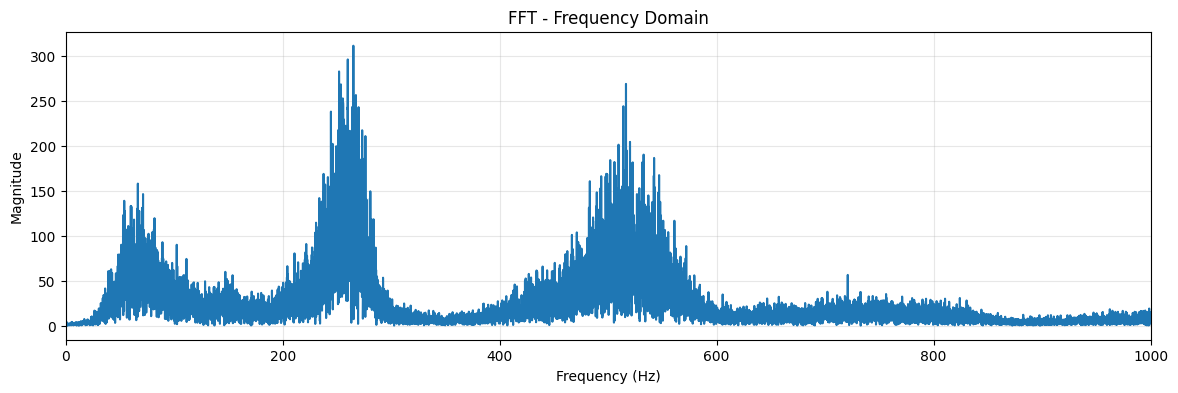

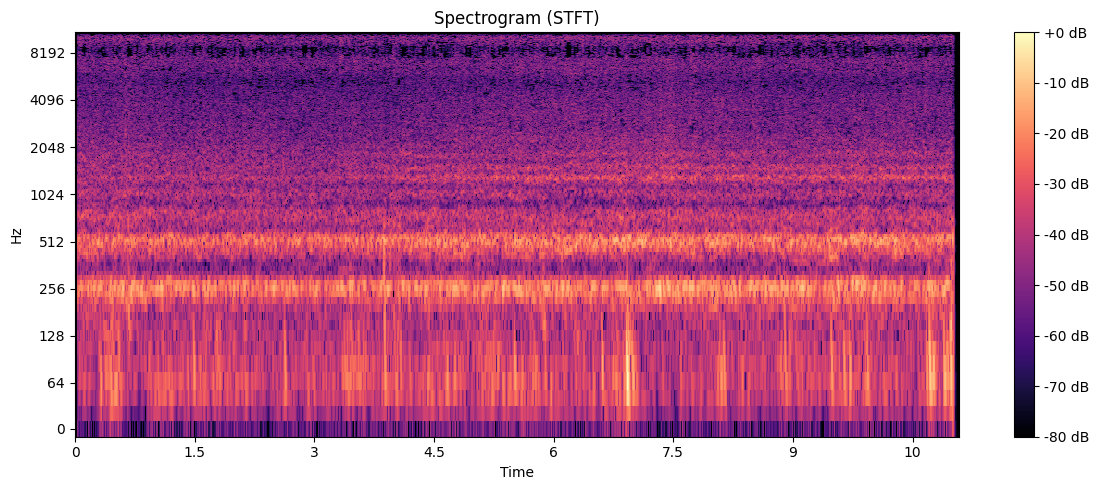


===== 분석 요약 =====
Waveform → 시간에 따른 진폭 변화
FFT → 전체 주파수 성분 분석
Spectrogram → 시간 + 주파수 동시 분석

===== 처리 파일: 장수말벌 크기, 소리.mp3 =====
Sampling Rate: 22050
Audio Length (samples): 562176
Duration (sec): 25.495510204081633


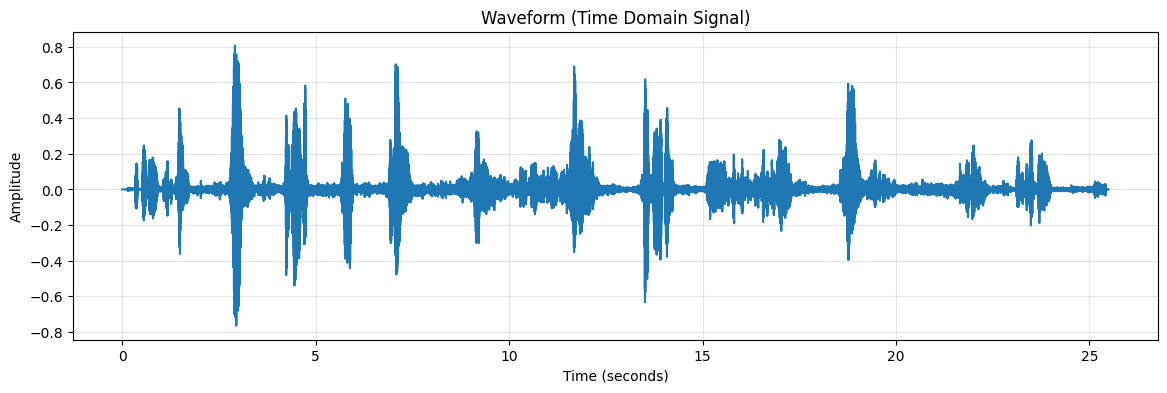

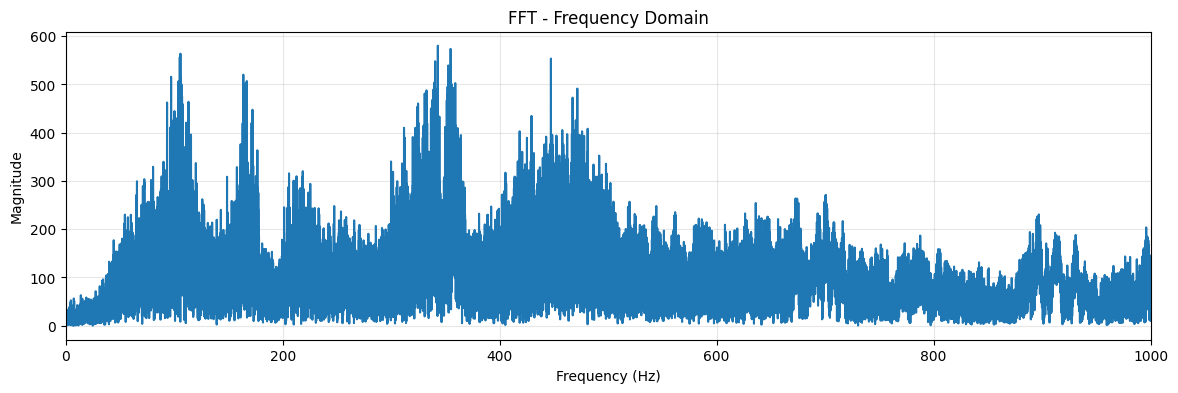

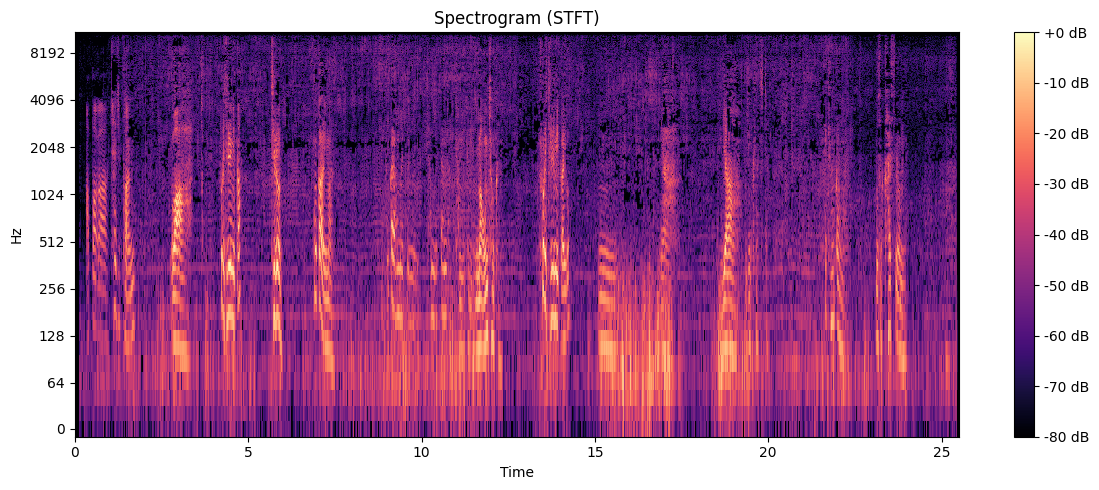


===== 분석 요약 =====
Waveform → 시간에 따른 진폭 변화
FFT → 전체 주파수 성분 분석
Spectrogram → 시간 + 주파수 동시 분석

===== 처리 파일: 벌 윙윙 거리는 소리.mp3 =====
Sampling Rate: 22050
Audio Length (samples): 299008
Duration (sec): 13.56045351473923


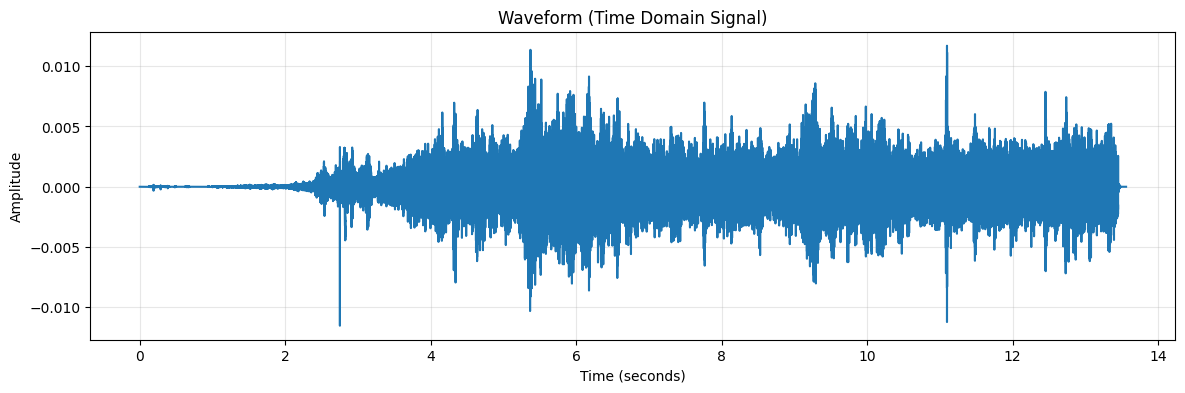

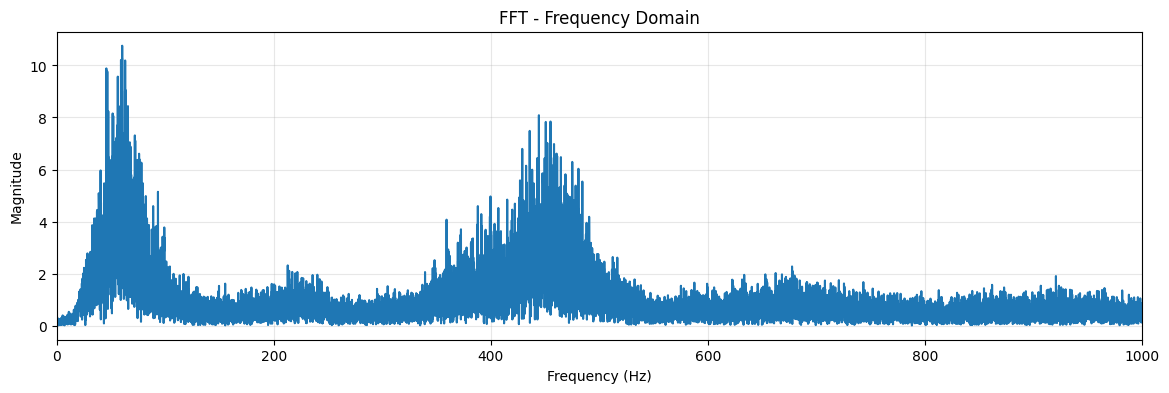

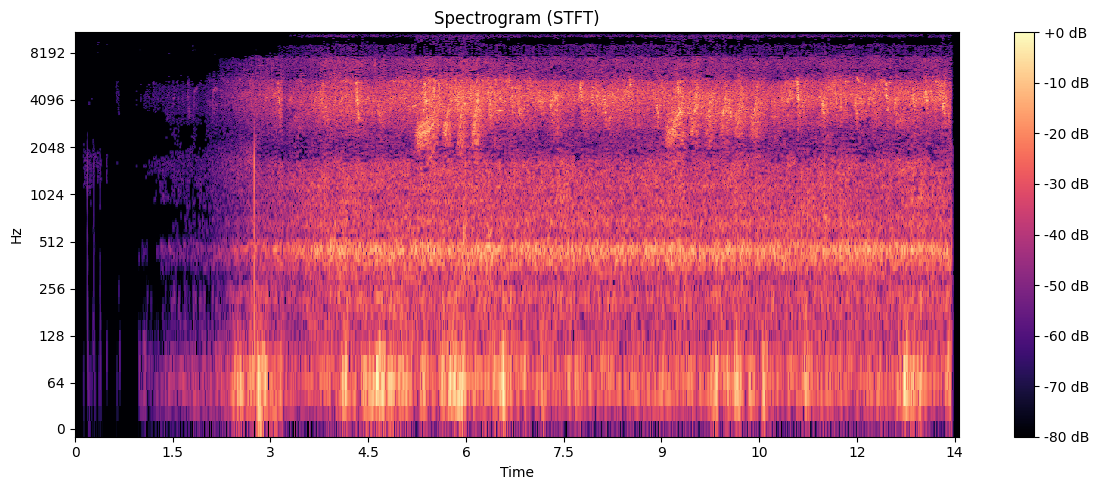


===== 분석 요약 =====
Waveform → 시간에 따른 진폭 변화
FFT → 전체 주파수 성분 분석
Spectrogram → 시간 + 주파수 동시 분석

===== 처리 파일: 벌소리.mp3 =====
Sampling Rate: 22050
Audio Length (samples): 308224
Duration (sec): 13.978412698412699


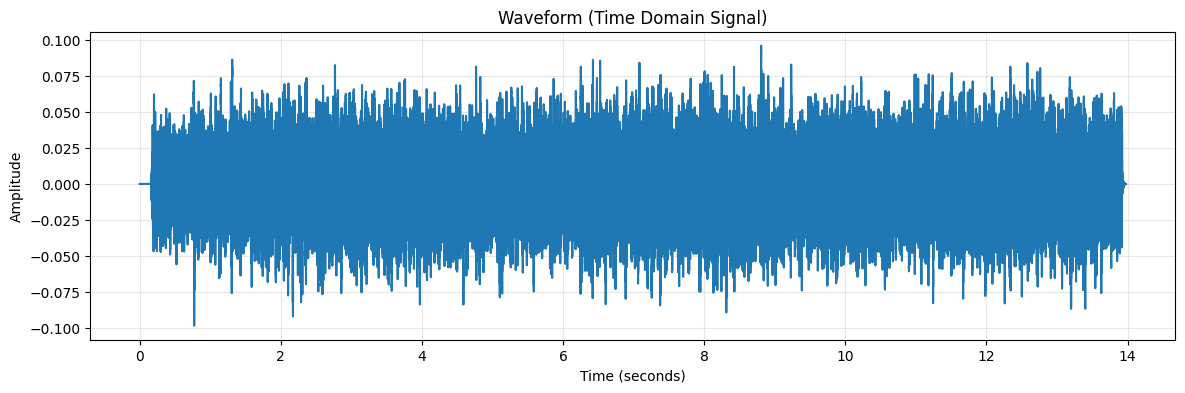

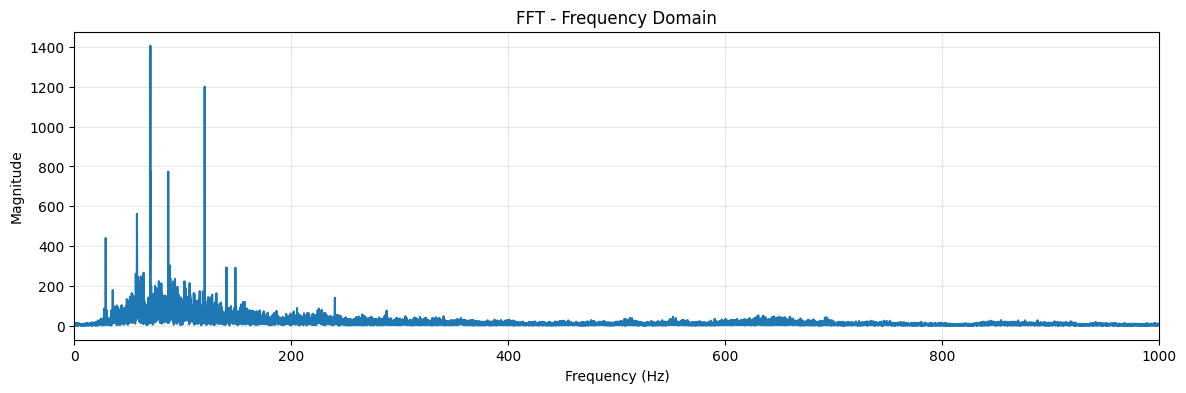

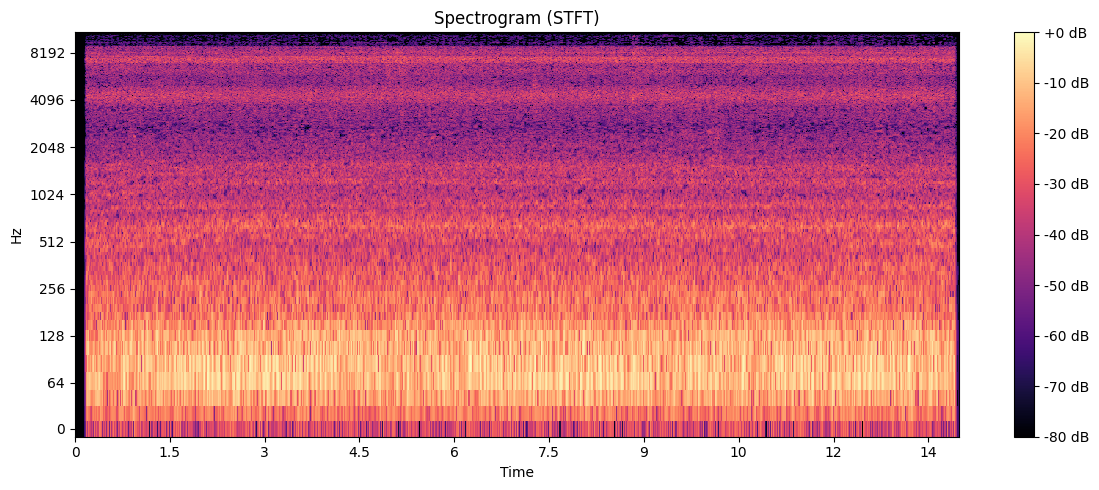


===== 분석 요약 =====
Waveform → 시간에 따른 진폭 변화
FFT → 전체 주파수 성분 분석
Spectrogram → 시간 + 주파수 동시 분석


In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import os
import random

# ============================================================
# 2. 폴더 경로 설정
# ============================================================
folder_path = r"C:\Users\hoons\OneDrive\바탕 화면\휴먼교육 실습\휴먼 프로젝트\동적 소음 검증용"

# ============================================================
# 3. 오디오 파일 목록 가져오기
# ============================================================
audio_extensions = ('.mp3', '.wav', '.flac', '.ogg')

file_list = [
    os.path.join(folder_path, f)
    for f in os.listdir(folder_path)
    if f.lower().endswith(audio_extensions)
]

# 5개 랜덤 선택 (파일이 부족하면 있는 만큼)
sample_size = min(5, len(file_list))
selected_files = random.sample(file_list, sample_size)

print(f"총 파일 수: {len(file_list)}")
print(f"선택된 파일 수: {len(selected_files)}")

# ============================================================
# 4. 파일별 기존 코드 그대로 실행
# ============================================================
for file_path in selected_files:

    print(f"\n===== 처리 파일: {os.path.basename(file_path)} =====")

    # ---------------- 오디오 로드 ----------------
    y, sr = librosa.load(file_path, sr=22050)

    duration = len(y) / sr

    print("Sampling Rate:", sr)
    print("Audio Length (samples):", len(y))
    print("Duration (sec):", duration)

    # ========================================================
    # Waveform
    # ========================================================
    time = np.linspace(0, duration, len(y))

    plt.figure(figsize=(14, 4))
    plt.plot(time, y)
    plt.title("Waveform (Time Domain Signal)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.show()

    # ========================================================
    # FFT
    # ========================================================
    fft = np.fft.rfft(y)
    fft_magnitude = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y), d=1/sr)

    plt.figure(figsize=(14, 4))
    plt.plot(freqs, fft_magnitude)
    plt.title("FFT - Frequency Domain")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 1000)
    plt.grid(alpha=0.3)
    plt.show()

    # ========================================================
    # STFT & Spectrogram
    # ========================================================
    stft = librosa.stft(y, n_fft=1024, hop_length=256)
    magnitude = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(magnitude, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=256,
        x_axis="time",
        y_axis="log"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram (STFT)")
    plt.tight_layout()
    plt.show()

    # ========================================================
    # 요약
    # ========================================================
    print("\n===== 분석 요약 =====")
    print("Waveform → 시간에 따른 진폭 변화")
    print("FFT → 전체 주파수 성분 분석")
    print("Spectrogram → 시간 + 주파수 동시 분석")